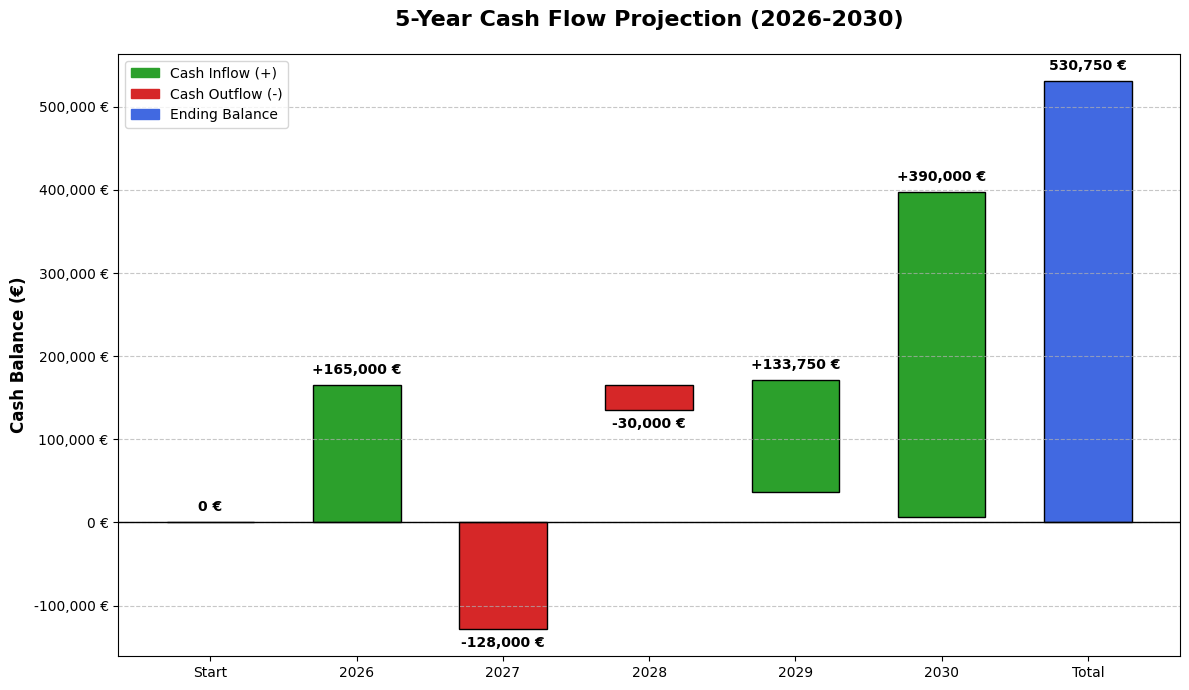

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# 1. Definimos los datos, añadiendo la barra "Total" al final
labels = ["Start", "2026", "2027", "2028", "2029", "2030", "Total"]
values = [0, 165000, -128000, -30000, 133750, 390000]

# Calculamos el saldo final para la última columna ("Total")
total = sum(values)
values.append(total)

# Acumulado para calcular dónde empieza cada barra ("el escalón")
cumulative = np.cumsum(values[:-1]) 
cumulative = np.insert(cumulative, 0, 0)

# 2. Preparamos el gráfico (más grande para que los números respiren)
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Dibujamos las barras con un bucle
for i in range(len(values)):
    if i == 0:
        # Barra Inicial
        color = "dimgrey"
        bottom = 0
        height = values[i]
        label_y = height
    elif i == len(values) - 1:
        # Barra Total Final
        color = "royalblue"
        bottom = 0
        height = values[i]
        label_y = height
    else:
        # Barras intermedias (variación anual)
        bottom = cumulative[i-1]
        height = values[i]
        color = "#2ca02c" if height >= 0 else "#d62728" # Verde si es +, Rojo si es -
        label_y = bottom + height
        
    ax.bar(labels[i], height, bottom=bottom, color=color, edgecolor="black", width=0.6)
    
    # 4. Añadimos los números encima (o debajo) de cada barra
    if i == 0: 
        ax.text(i, 10000, f"{values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    elif i == len(values) - 1: # Formato del Total
        ax.text(i, label_y + 10000, f"{values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    else:
        # Mostrar el valor del año exacto con su signo (+ o -)
        y_pos = label_y + (10000 if height >= 0 else -25000)
        ax.text(i, y_pos, f"{height:+,.0f} €", ha="center", va="bottom", fontweight="bold")

# 5. Formateo y Estilo
ax.set_ylabel("Cash Balance (€)", fontsize=12, fontweight="bold")
ax.set_title("5-Year Cash Flow Projection (2026-2030)", fontsize=16, fontweight="bold", pad=20)

# Poner formato de € en el eje Y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f} €".format(x)))

# Añadir cuadrícula horizontal sutil y una línea sólida en el 0
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.axhline(0, color='black', linewidth=1)

# 6. Añadimos la Leyenda Personalizada
pos_patch = mpatches.Patch(color='#2ca02c', label='Cash Inflow (+)')
neg_patch = mpatches.Patch(color='#d62728', label='Cash Outflow (-)')
tot_patch = mpatches.Patch(color='royalblue', label='Ending Balance')
ax.legend(handles=[pos_patch, neg_patch, tot_patch], loc='upper left')

# Ajustamos márgenes y mostramos el gráfico
plt.tight_layout()
plt.show()

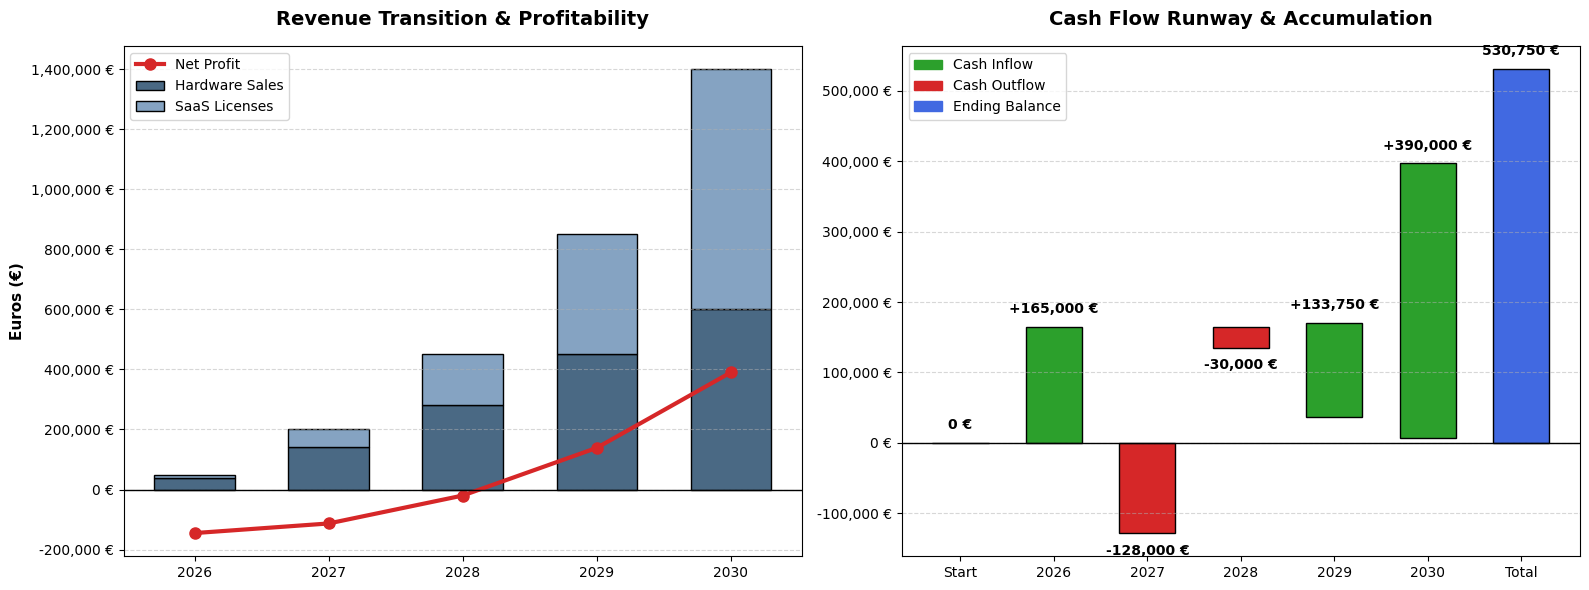

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# --- DATOS DEL MODELO ---
years = ["2026", "2027", "2028", "2029", "2030"]
hw_rev = np.array([40000, 140000, 280000, 450000, 600000])
saas_rev = np.array([10000, 60000, 170000, 400000, 800000])
net_profit = np.array([-145000, -113000, -20000, 138750, 390000])

wf_labels = ["Start", "2026", "2027", "2028", "2029", "2030", "Total"]
wf_values = [0, 165000, -128000, -30000, 133750, 390000]
wf_total = sum(wf_values)
wf_values.append(wf_total)
wf_cumulative = np.insert(np.cumsum(wf_values[:-1]), 0, 0)

# --- CONFIGURACIÓN DE LA FIGURA (1x2) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.25)

# --- GRÁFICO 1: INGRESOS VS BENEFICIO (BAR & LINE) ---
width = 0.6
ax1.bar(years, hw_rev, width, label='Hardware Sales', color='#4a6984', edgecolor='black')
ax1.bar(years, saas_rev, width, bottom=hw_rev, label='SaaS Licenses', color='#85a3c2', edgecolor='black')
ax1.plot(years, net_profit, color='#d62728', marker='o', linewidth=3, markersize=8, label='Net Profit')

ax1.set_title("Revenue Transition & Profitability", fontsize=14, fontweight="bold", pad=15)
ax1.set_ylabel("Euros (€)", fontsize=11, fontweight="bold")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f} €".format(x)))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=1)
ax1.legend(loc='upper left')

# --- GRÁFICO 2: CASCADA DE TESORERÍA (WATERFALL) ---
for i in range(len(wf_values)):
    if i == 0 or i == len(wf_values) - 1:
        color = "dimgrey" if i == 0 else "royalblue"
        bottom, height = 0, wf_values[i]
        label_y = height
    else:
        bottom = wf_cumulative[i-1]
        height = wf_values[i]
        color = "#2ca02c" if height >= 0 else "#d62728"
        label_y = bottom + height
        
    ax2.bar(wf_labels[i], height, bottom=bottom, color=color, edgecolor="black", width=0.6)
    
    # Etiquetas de datos
    y_pos = label_y + (15000 if height >= 0 else -35000)
    if i == 0:
        ax2.text(i, 15000, f"{wf_values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    elif i == len(wf_values) - 1:
        ax2.text(i, label_y + 15000, f"{wf_values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    else:
        ax2.text(i, y_pos, f"{height:+,.0f} €", ha="center", va="bottom", fontweight="bold")

ax2.set_title("Cash Flow Runway & Accumulation", fontsize=14, fontweight="bold", pad=15)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f} €".format(x)))
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=1)

pos_patch = mpatches.Patch(color='#2ca02c', label='Cash Inflow')
neg_patch = mpatches.Patch(color='#d62728', label='Cash Outflow')
tot_patch = mpatches.Patch(color='royalblue', label='Ending Balance')
ax2.legend(handles=[pos_patch, neg_patch, tot_patch], loc='upper left')

# --- GUARDAR Y MOSTRAR ---
plt.tight_layout()
plt.savefig('lucid_vision_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

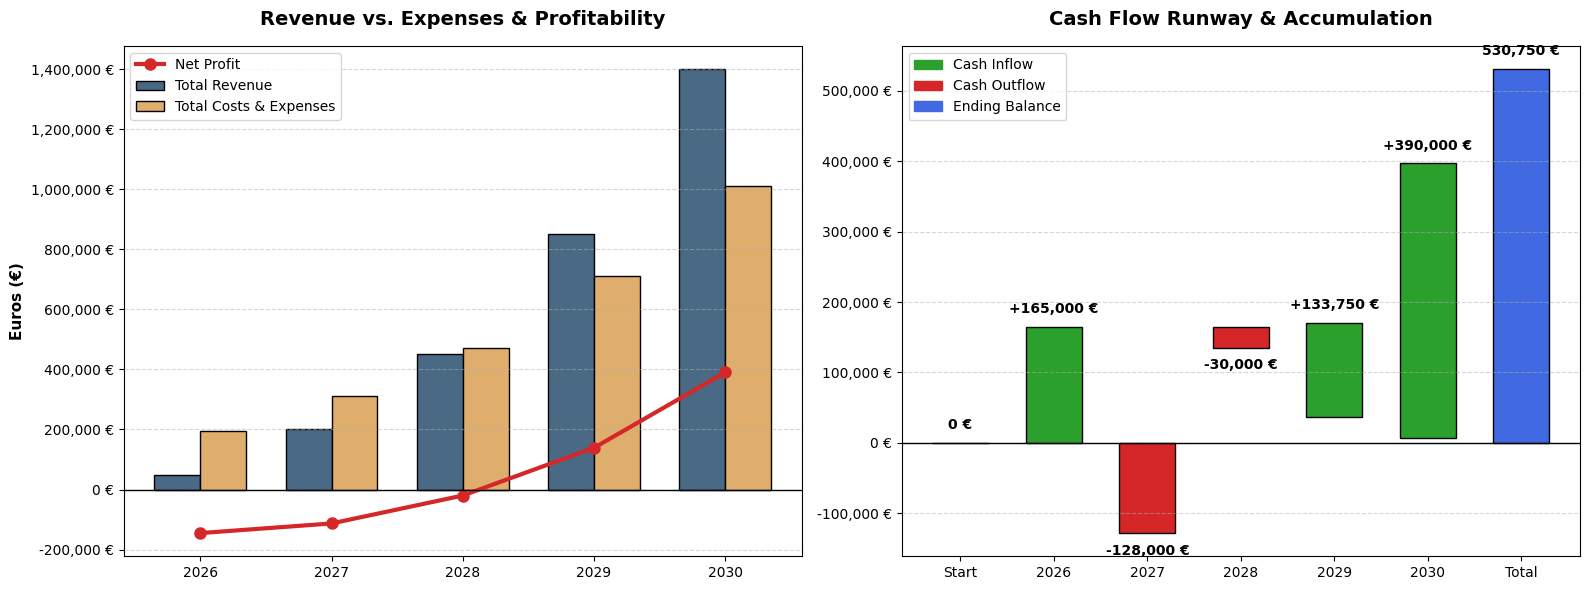

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# --- DATOS DEL MODELO ---
years = ["2026", "2027", "2028", "2029", "2030"]

# Datos de la Cuenta de Resultados (P&L)
total_revenue = np.array([50000, 200000, 450000, 850000, 1400000])
# Los gastos totales son la diferencia entre Ingresos y Beneficio Neto
total_costs = np.array([195000, 313000, 470000, 711250, 1010000]) 
net_profit = np.array([-145000, -113000, -20000, 138750, 390000])

# Datos de la Tesorería (Waterfall)
wf_labels = ["Start", "2026", "2027", "2028", "2029", "2030", "Total"]
wf_values = [0, 165000, -128000, -30000, 133750, 390000]
wf_total = sum(wf_values)
wf_values.append(wf_total)
wf_cumulative = np.insert(np.cumsum(wf_values[:-1]), 0, 0)

# --- CONFIGURACIÓN DE LA FIGURA (1x2) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.25)

# --- GRÁFICO 1: INGRESOS VS GASTOS (BAR & LINE) ---
x = np.arange(len(years))
width = 0.35

ax1.bar(x - width/2, total_revenue, width, label='Total Revenue', color='#4a6984', edgecolor='black')
ax1.bar(x + width/2, total_costs, width, label='Total Costs & Expenses', color='#e0ae6c', edgecolor='black')
ax1.plot(x, net_profit, color='#d62728', marker='o', linewidth=3, markersize=8, label='Net Profit')

ax1.set_title("Revenue vs. Expenses & Profitability", fontsize=14, fontweight="bold", pad=15)
ax1.set_ylabel("Euros (€)", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f} €".format(val)))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=1)
ax1.legend(loc='upper left')

# --- GRÁFICO 2: CASCADA DE TESORERÍA (WATERFALL) ---
for i in range(len(wf_values)):
    if i == 0 or i == len(wf_values) - 1:
        color = "dimgrey" if i == 0 else "royalblue"
        bottom, height = 0, wf_values[i]
        label_y = height
    else:
        bottom = wf_cumulative[i-1]
        height = wf_values[i]
        color = "#2ca02c" if height >= 0 else "#d62728"
        label_y = bottom + height
        
    ax2.bar(wf_labels[i], height, bottom=bottom, color=color, edgecolor="black", width=0.6)
    
    y_pos = label_y + (15000 if height >= 0 else -35000)
    if i == 0:
        ax2.text(i, 15000, f"{wf_values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    elif i == len(wf_values) - 1:
        ax2.text(i, label_y + 15000, f"{wf_values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    else:
        ax2.text(i, y_pos, f"{height:+,.0f} €", ha="center", va="bottom", fontweight="bold")

ax2.set_title("Cash Flow Runway & Accumulation", fontsize=14, fontweight="bold", pad=15)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f} €".format(val)))
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=1)

pos_patch = mpatches.Patch(color='#2ca02c', label='Cash Inflow')
neg_patch = mpatches.Patch(color='#d62728', label='Cash Outflow')
tot_patch = mpatches.Patch(color='royalblue', label='Ending Balance')
ax2.legend(handles=[pos_patch, neg_patch, tot_patch], loc='upper left')

# --- GUARDAR Y MOSTRAR ---
plt.tight_layout()
plt.savefig('lucid_vision_forecast_with_expenses.png', dpi=300, bbox_inches='tight')
plt.show()

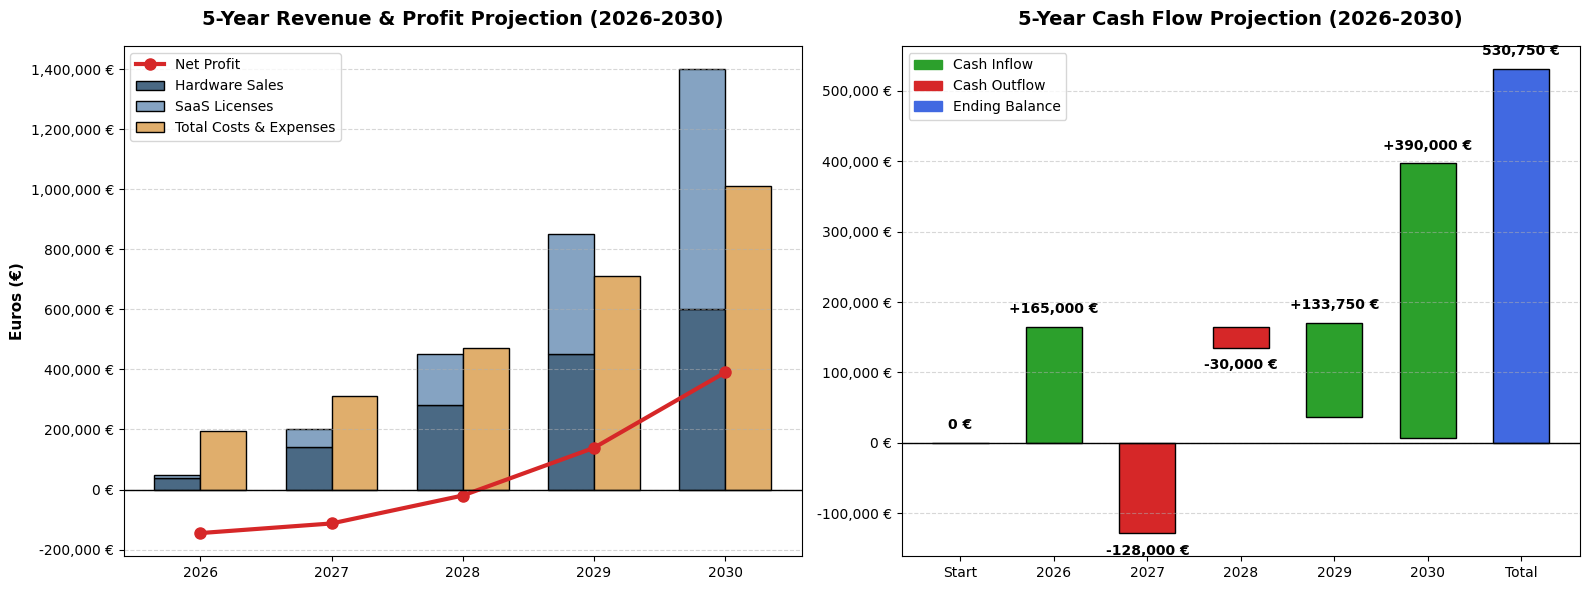

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# --- DATOS DEL MODELO ---
years = ["2026", "2027", "2028", "2029", "2030"]

# Ingresos desglosados (para hacer la barra apilada)
hw_rev = np.array([40000, 140000, 280000, 450000, 600000])
saas_rev = np.array([10000, 60000, 170000, 400000, 800000])

# Gastos y Beneficio Neto
total_costs = np.array([195000, 313000, 470000, 711250, 1010000]) 
net_profit = np.array([-145000, -113000, -20000, 138750, 390000])

# Datos de la Tesorería (Waterfall)
wf_labels = ["Start", "2026", "2027", "2028", "2029", "2030", "Total"]
wf_values = [0, 165000, -128000, -30000, 133750, 390000]
wf_total = sum(wf_values)
wf_values.append(wf_total)
wf_cumulative = np.insert(np.cumsum(wf_values[:-1]), 0, 0)

# --- CONFIGURACIÓN DE LA FIGURA (1x2) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.25)

# --- GRÁFICO 1: INGRESOS APILADOS VS GASTOS (BAR & LINE) ---
x = np.arange(len(years))
width = 0.35

# Barra 1: Ingresos (Apilada) -> desplazada a la izquierda
ax1.bar(x - width/2, hw_rev, width, label='Hardware Sales', color='#4a6984', edgecolor='black')
ax1.bar(x - width/2, saas_rev, width, bottom=hw_rev, label='SaaS Licenses', color='#85a3c2', edgecolor='black')

# Barra 2: Gastos Totales -> desplazada a la derecha
ax1.bar(x + width/2, total_costs, width, label='Total Costs & Expenses', color='#e0ae6c', edgecolor='black')

# Línea: Beneficio Neto -> centrada
ax1.plot(x, net_profit, color='#d62728', marker='o', linewidth=3, markersize=8, label='Net Profit')


ax1.set_title("5-Year Revenue & Profit Projection (2026-2030)", fontsize=14, fontweight="bold", pad=15)
ax1.set_ylabel("Euros (€)", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f} €".format(val)))
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=1)
ax1.legend(loc='upper left')

# --- GRÁFICO 2: CASCADA DE TESORERÍA (WATERFALL) ---
for i in range(len(wf_values)):
    if i == 0 or i == len(wf_values) - 1:
        color = "dimgrey" if i == 0 else "royalblue"
        bottom, height = 0, wf_values[i]
        label_y = height
    else:
        bottom = wf_cumulative[i-1]
        height = wf_values[i]
        color = "#2ca02c" if height >= 0 else "#d62728"
        label_y = bottom + height
        
    ax2.bar(wf_labels[i], height, bottom=bottom, color=color, edgecolor="black", width=0.6)
    
    y_pos = label_y + (15000 if height >= 0 else -35000)
    if i == 0:
        ax2.text(i, 15000, f"{wf_values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    elif i == len(wf_values) - 1:
        ax2.text(i, label_y + 15000, f"{wf_values[i]:,.0f} €", ha="center", va="bottom", fontweight="bold")
    else:
        ax2.text(i, y_pos, f"{height:+,.0f} €", ha="center", va="bottom", fontweight="bold")

ax2.set_title("5-Year Cash Flow Projection (2026-2030)", fontsize=14, fontweight="bold", pad=15)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f} €".format(val)))
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=1)

pos_patch = mpatches.Patch(color='#2ca02c', label='Cash Inflow')
neg_patch = mpatches.Patch(color='#d62728', label='Cash Outflow')
tot_patch = mpatches.Patch(color='royalblue', label='Ending Balance')
ax2.legend(handles=[pos_patch, neg_patch, tot_patch], loc='upper left')

# --- GUARDAR Y MOSTRAR ---
plt.tight_layout()
plt.show()